# Alzheimer's Disease — Two Network Animations

**Animation 1 — Biological AD Progression**  
Tau pathology spreads through the connectome following **Braak staging** (transentorhinal → limbic → isocortical).  
Each node is placed at its approximate anatomical 2-D position. Colour encodes tau burden over time.

**Animation 2 — Motter–Lai Cascade from the Entorhinal Epicentre**  
The same connectome with Motter–Lai load redistribution.  
Node colour encodes fractional load relative to capacity; overloaded nodes collapse round by round.

Both are saved as **GIF** files and displayed inline.

In [1]:
import os
os.environ['VTK_DEFAULT_RENDER_WINDOW_TYPE'] = 'OSMesa'
import matplotlib
matplotlib.use('Agg')   # headless — must be before pyplot import
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe
from matplotlib.colors import Normalize, LinearSegmentedColormap
import matplotlib.cm as cm
import numpy as np
import networkx as nx
from copy import deepcopy
from IPython.display import Image, display

from enigmatoolbox.datasets import load_sc

np.random.seed(42)
print('Imports OK')

Imports OK


---
## Setup: Brain Layout & Data

In [2]:
# ── Load connectivity ─────────────────────────────────────────────────────────
sc_ctx, labels_arr, _, _ = load_sc()
labels = list(labels_arr)
N = sc_ctx.shape[0]

# ── Anatomical 2-D positions (axial-like view, right hemisphere right) ────────
# Coordinate system: x = medial(0)→lateral(1), y = posterior(-1)→anterior(+1)
# Left hemisphere gets negative x, right gets positive x.
#
# Region name → (|x|, y) for right hemisphere; left mirrors to negative x
REGION_XY = {
    'bankssts':                 (0.72, -0.02),
    'caudalanteriorcingulate':  (0.12,  0.32),
    'caudalmiddlefrontal':      (0.52,  0.50),
    'cuneus':                   (0.18, -0.82),
    'entorhinal':               (0.42, -0.62),
    'fusiform':                 (0.58, -0.60),
    'inferiorparietal':         (0.68, -0.32),
    'inferiortemporal':         (0.72, -0.50),
    'isthmuscingulate':         (0.16, -0.42),
    'lateraloccipital':         (0.62, -0.80),
    'lateralorbitofrontal':     (0.54,  0.80),
    'lingual':                  (0.30, -0.75),
    'medialorbitofrontal':      (0.20,  0.88),
    'middletemporal':           (0.78, -0.18),
    'parahippocampal':          (0.36, -0.52),
    'paracentral':              (0.22,  0.08),
    'parsopercularis':          (0.64,  0.42),
    'parsorbitalis':            (0.62,  0.76),
    'parstriangularis':         (0.60,  0.58),
    'pericalcarine':            (0.10, -0.90),
    'postcentral':              (0.58,  0.14),
    'posteriorcingulate':       (0.13, -0.22),
    'precentral':               (0.58,  0.30),
    'precuneus':                (0.22, -0.32),
    'rostralanteriorcingulate': (0.11,  0.52),
    'rostralmiddlefrontal':     (0.50,  0.66),
    'superiorfrontal':          (0.34,  0.76),
    'superiorparietal':         (0.40, -0.46),
    'superiortemporal':         (0.76,  0.08),
    'supramarginal':            (0.70, -0.10),
    'frontalpole':              (0.44,  0.96),
    'temporalpole':             (0.74,  0.42),
    'transversetemporal':       (0.70,  0.20),
    'insula':                   (0.86,  0.24),
}

# Build position dict for all 68 nodes
pos = {}
for i, lab in enumerate(labels):
    hemi, region = lab.split('_', 1)
    rx, ry = REGION_XY.get(region, (0.5, 0.0))
    sign = -1.0 if hemi == 'L' else 1.0
    pos[i] = (sign * rx, ry)

# ── Braak stage membership ────────────────────────────────────────────────────
BRAAK_KW = {
    1: ['entorhinal', 'parahippocampal'],
    2: ['isthmuscingulate', 'inferiortemporal', 'middletemporal', 'fusiform', 'lingual'],
    3: ['posteriorcingulate', 'precuneus', 'inferiorparietal', 'superiorparietal',
        'lateraloccipital', 'superiorfrontal', 'rostralmiddlefrontal', 'caudalmiddlefrontal'],
}

braak_stage = np.zeros(N, dtype=int)  # 0 = unaffected
for stage, kws in BRAAK_KW.items():
    for i, lab in enumerate(labels):
        if any(kw in lab.lower() for kw in kws):
            braak_stage[i] = stage

print('Braak stage counts:', dict(zip(*np.unique(braak_stage, return_counts=True))))
print('Layout ready for', N, 'nodes')

Braak stage counts: {np.int64(0): np.int64(38), np.int64(1): np.int64(4), np.int64(2): np.int64(10), np.int64(3): np.int64(16)}
Layout ready for 68 nodes


In [3]:
# ── Drawing helpers ────────────────────────────────────────────────────────────
def draw_brain_outline(ax):
    """Draw schematic left/right brain lobes as background ellipses."""
    from matplotlib.patches import Ellipse, FancyArrowPatch
    for sign in [-1, 1]:
        # Outer cortex
        e = Ellipse((sign * 0.48, 0.05), width=1.10, height=2.10,
                    linewidth=1.5, edgecolor='#cccccc', facecolor='#f9f9f9', zorder=0)
        ax.add_patch(e)
    # Midline gap
    ax.axvline(0, color='#dddddd', lw=1, ls='--', zorder=1)
    # Anterior / posterior labels
    ax.text(0, 1.05, 'Anterior (Frontal)', ha='center', va='bottom', fontsize=8, color='gray')
    ax.text(0, -1.05, 'Posterior (Occipital)', ha='center', va='top', fontsize=8, color='gray')
    ax.text(-1.05, 0.0, 'Left\nHemisphere', ha='right', va='center', fontsize=8, color='gray')
    ax.text( 1.05, 0.0, 'Right\nHemisphere', ha='left', va='center', fontsize=8, color='gray')

def edge_alpha_from_weight(w, w_max, base=0.08, top=0.30):
    return base + (top - base) * (w / w_max)

W_MAX = sc_ctx.max()
EDGES = [(i, j) for i in range(N) for j in range(i+1, N) if sc_ctx[i, j] > 0]

print(f'Total edges: {len(EDGES)}')

Total edges: 697


---
## Animation 1: Biological AD Progression (Braak Tau Spreading)

In [4]:
# ── Colour scheme ─────────────────────────────────────────────────────────────
# healthy = steel blue, tau accumulating = yellow → orange → dark red
TAU_CMAP = LinearSegmentedColormap.from_list(
    'tau', ['#4e8ec9', '#ffffff', '#ffffb2', '#fd8d3c', '#bd0026', '#67000d'])

# ── Build frame-by-frame tau burden ──────────────────────────────────────────
# Each Braak stage arrives in waves; within a stage tau gradually builds up.
# We model tau_burden[i] as a value in [0, 1] (0=healthy, 1=fully degenerated)
#
# Timeline (conceptual):
#  frames 0-4:    Baseline — healthy brain
#  frames 5-14:   Braak I-II seeding (entorhinal, parahippocampal)
#  frames 15-24:  Braak III-IV spread (limbic circuit)
#  frames 25-38:  Braak V-VI spread (isocortical)
#  frames 39-44:  End state — pause on final frame

TOTAL_FRAMES = 45

def tau_trajectory(stage, frame):
    """Return tau burden [0,1] for a node of given Braak stage at frame."""
    if stage == 0:
        # Not in Braak map — very slow background accumulation
        return min(0.15, frame / TOTAL_FRAMES * 0.15)
    windows = {1: (5, 14), 2: (15, 24), 3: (25, 38)}
    start, end = windows[stage]
    if frame < start:
        return 0.0
    if frame >= end:
        return 1.0
    return (frame - start) / (end - start)

# Clinical phase labels
def clinical_label(frame):
    if frame < 5:  return 'Pre-clinical (Silent)'
    if frame < 15: return 'Pre-clinical → Braak I-II  |  Entorhinal Tau Seeding'
    if frame < 25: return 'MCI / Early AD  |  Braak III-IV  |  Limbic Spread'
    if frame < 39: return 'Moderate–Severe AD  |  Braak V-VI  |  Isocortical Spread'
    return 'End-stage AD  |  Widespread Tau Pathology'

stage_bar_colors = {0: '#4e8ec9', 1: '#fd8d3c', 2: '#d73027', 3: '#67000d'}

print('Generating Animation 1: Biological AD Tau Spreading...')

fig, ax = plt.subplots(figsize=(11, 8))
fig.patch.set_facecolor('#111111')
ax.set_facecolor('#111111')
ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.12, 1.15)
ax.set_aspect('equal')
ax.axis('off')

# Static title
fig.suptitle('Alzheimer\'s Disease — Biological Tau Spreading (Braak Staging)',
             color='white', fontsize=13, fontweight='bold', y=0.97)

# ── Draw static edges once ────────────────────────────────────────────────────
edge_artists = []
for (i, j) in EDGES:
    xi, yi = pos[i]; xj, yj = pos[j]
    alp = edge_alpha_from_weight(sc_ctx[i, j], W_MAX, 0.04, 0.18)
    line, = ax.plot([xi, xj], [yi, yj], '-', color='#aaaaaa',
                    alpha=alp, lw=0.4, zorder=2)
    edge_artists.append(line)

# ── Brain outline ─────────────────────────────────────────────────────────────
from matplotlib.patches import Ellipse
for sign in [-1, 1]:
    e = Ellipse((sign * 0.48, 0.05), width=1.10, height=2.10,
                linewidth=1.2, edgecolor='#444444', facecolor='none', zorder=1)
    ax.add_patch(e)
ax.axvline(0, color='#333333', lw=1.0, ls='--', zorder=1)
ax.text( 0,  1.08, 'Anterior', ha='center', va='bottom', fontsize=7, color='#777777')
ax.text( 0, -1.06, 'Posterior', ha='center', va='top',    fontsize=7, color='#777777')
ax.text(-1.08, 0, 'L', ha='right', va='center', fontsize=9, color='#777777', fontweight='bold')
ax.text( 1.08, 0, 'R', ha='left',  va='center', fontsize=9, color='#777777', fontweight='bold')

# ── Node scatter artists ───────────────────────────────────────────────────────
node_x = np.array([pos[i][0] for i in range(N)])
node_y = np.array([pos[i][1] for i in range(N)])

# Node sizes: scale by degree
deg = sc_ctx.sum(axis=1)
node_size = 40 + 120 * (deg - deg.min()) / (deg.max() - deg.min() + 1e-9)

scatter = ax.scatter(node_x, node_y, s=node_size,
                     c=np.zeros(N), cmap=TAU_CMAP, vmin=0, vmax=1,
                     edgecolors='white', linewidths=0.5, zorder=5)

# Label key AD regions
KEY_LABELS = {'L_entorhinal': 'Entorhinal\n(Braak I)',
              'L_parahippocampal': 'Parahippo.',
              'L_isthmuscingulate': 'Isthmus\nCing.',
              'L_posteriorcingulate': 'Post.\nCing.',
              'L_precuneus': 'Precuneus',
              'L_inferiorparietal': 'Inf.\nParietal'}
for lab_key, txt in KEY_LABELS.items():
    if lab_key in labels:
        idx = labels.index(lab_key)
        ax.text(pos[idx][0] - 0.04, pos[idx][1] + 0.06, txt,
                fontsize=6, color='#dddddd', ha='center', zorder=6,
                path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])

# Dynamic text
title_txt = ax.text(0, -1.00, '', ha='center', va='top',
                    fontsize=9, color='white', fontweight='bold',
                    bbox=dict(facecolor='#222222', edgecolor='none', pad=4))
frame_txt  = ax.text(-1.10, 1.05, '', ha='left', va='top', fontsize=8, color='#aaaaaa')

# Colourbar
sm = cm.ScalarMappable(cmap=TAU_CMAP, norm=Normalize(0, 1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, fraction=0.02, pad=0.01)
cbar.set_label('Tau Burden', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white', fontsize=8)

# Legend
leg_patches = [
    mpatches.Patch(color=TAU_CMAP(0.0), label='Healthy'),
    mpatches.Patch(color=TAU_CMAP(0.35), label='Braak I-II (Entorhinal)'),
    mpatches.Patch(color=TAU_CMAP(0.65), label='Braak III-IV (Limbic)'),
    mpatches.Patch(color=TAU_CMAP(1.00), label='Braak V-VI (Isocortical)'),
]
ax.legend(handles=leg_patches, loc='upper left', fontsize=7,
          facecolor='#222222', edgecolor='#555555', labelcolor='white')

def update_bio(frame):
    tau = np.array([tau_trajectory(braak_stage[i], frame) for i in range(N)])
    scatter.set_array(tau)
    # Pulse the actively spreading nodes
    sizes = node_size.copy()
    if 5 <= frame < 15:
        active = braak_stage == 1
    elif 15 <= frame < 25:
        active = braak_stage == 2
    elif 25 <= frame < 39:
        active = braak_stage == 3
    else:
        active = np.zeros(N, dtype=bool)
    pulse = 1.0 + 0.4 * np.sin(frame * 0.7)   # oscillate size
    sizes[active] *= pulse
    scatter.set_sizes(sizes)
    title_txt.set_text(clinical_label(frame))
    frame_txt.set_text(f'Frame {frame+1}/{TOTAL_FRAMES}')
    return scatter, title_txt, frame_txt

anim1 = animation.FuncAnimation(fig, update_bio, frames=TOTAL_FRAMES,
                                  interval=180, blit=True)
writer = animation.PillowWriter(fps=8)
anim1.save('ad_bio_animation.gif', writer=writer, dpi=130)
plt.close(fig)
print('Saved: ad_bio_animation.gif')

Generating Animation 1: Biological AD Tau Spreading...
Saved: ad_bio_animation.gif


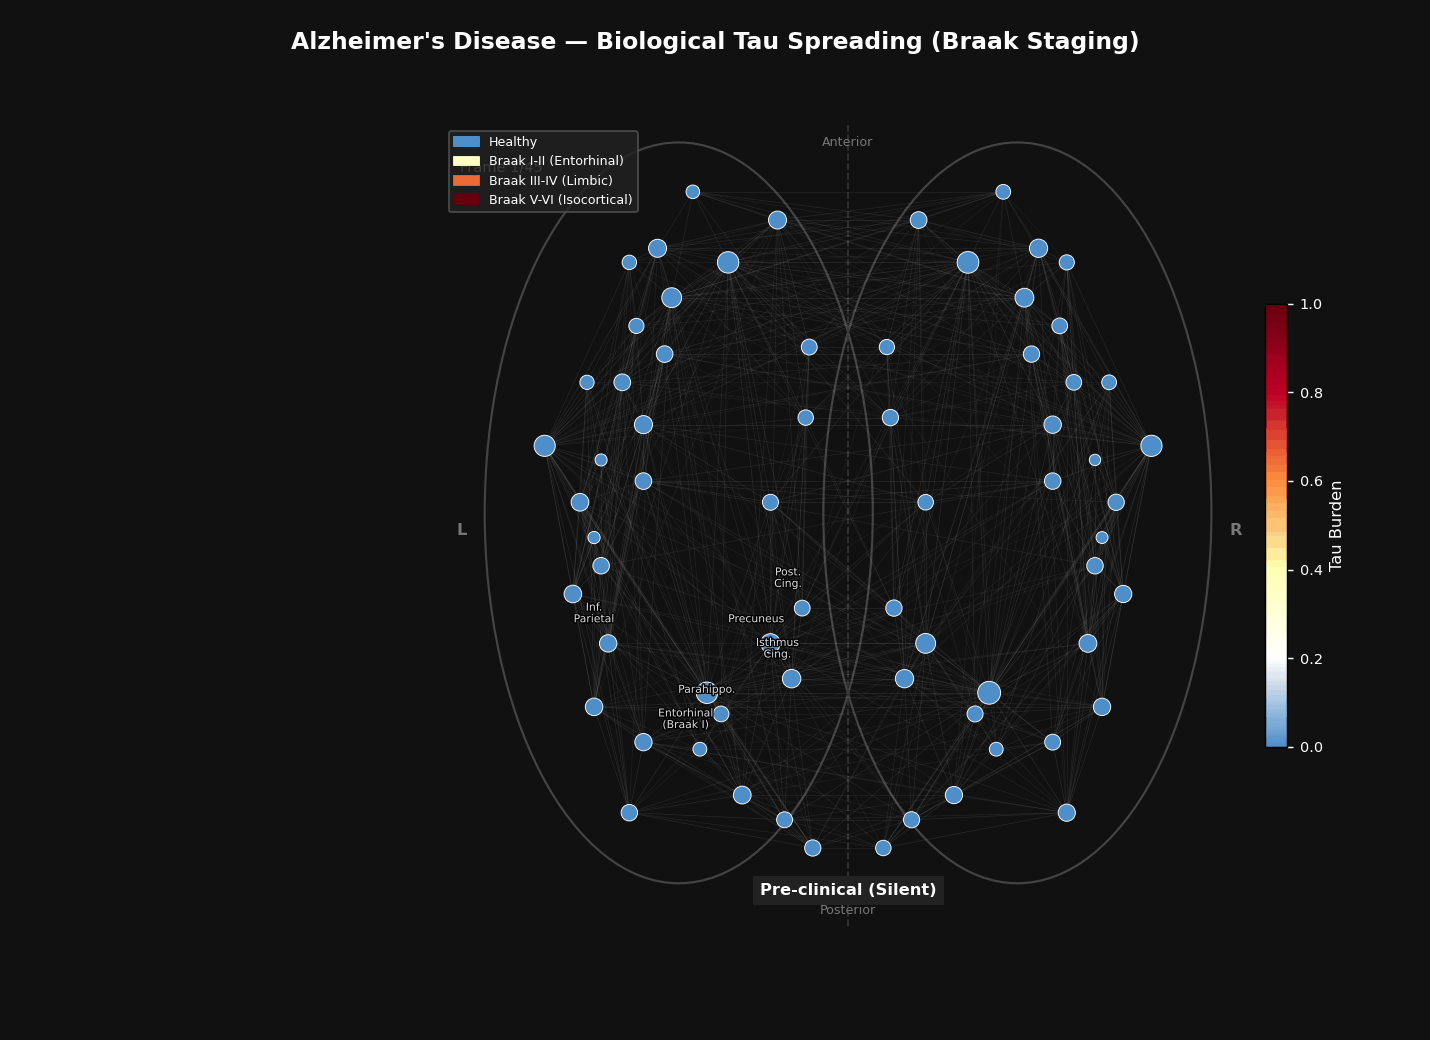

In [5]:
display(Image('ad_bio_animation.gif'))

---
## Animation 2: Motter–Lai Cascade from Entorhinal Cortex

In [6]:
# ── Run the cascade and record per-round state ────────────────────────────────
ALPHA_ANIM = 0.3   # moderate network reserve (models early-stage cognitive reserve)

entorhinal_seed = labels.index('L_entorhinal')

def run_motter_lai_trace(A, seed, alpha):
    """
    Returns:
      history     : list of sets — nodes removed per round (round 0 = seed)
      load_history: list of dicts {node_orig_idx: fractional_load} per round
      C           : capacity dict
    """
    N_total = A.shape[0]
    G0 = nx.from_numpy_array((A > 0).astype(float))
    L0 = nx.betweenness_centrality(G0, normalized=False)
    C  = {i: (1 + alpha) * L0[i] for i in range(N_total)}

    # Fractional load: L[i] / C[i] — values > 1 mean overloaded
    def frac_loads(active_nodes):
        if len(active_nodes) < 2:
            return {i: 0.0 for i in active_nodes}
        sub = A[np.ix_(active_nodes, active_nodes)]
        Gs  = nx.from_numpy_array((sub > 0).astype(float))
        Ls  = nx.betweenness_centrality(Gs, normalized=False)
        out = {}
        for new_i, orig_i in enumerate(active_nodes):
            cap = C[orig_i]
            out[orig_i] = Ls[new_i] / cap if cap > 1e-9 else 0.0
        return out

    active  = [i for i in range(N_total) if i != seed]
    removed = {seed}
    history      = [{seed}]
    load_history = [frac_loads(active)]

    for _ in range(N_total):
        if len(active) < 2:
            break
        fl = frac_loads(active)
        overloaded = {orig_i for orig_i, frac in fl.items() if frac > 1.0}
        if not overloaded:
            break
        removed.update(overloaded)
        history.append(overloaded)
        active = [i for i in active if i not in overloaded]
        load_history.append(frac_loads(active))

    return history, load_history, C

print(f'Running Motter-Lai cascade from L_entorhinal (idx {entorhinal_seed}), α={ALPHA_ANIM}...')
ml_history, ml_loads, ml_C = run_motter_lai_trace(sc_ctx, entorhinal_seed, ALPHA_ANIM)

n_rounds = len(ml_history)
all_failed = set()
for s in ml_history:
    all_failed.update(s)

print(f'Cascade rounds: {n_rounds}')
print(f'Total nodes failed: {len(all_failed)} / {N}')
for r, s in enumerate(ml_history):
    tag = '(seed)' if r == 0 else f'(cascade round {r})'
    print(f'  Round {r} {tag}: {[labels[i] for i in s]}')

Running Motter-Lai cascade from L_entorhinal (idx 4), α=0.3...
Cascade rounds: 1
Total nodes failed: 1 / 68
  Round 0 (seed): [np.str_('L_entorhinal')]


In [7]:
# ── Build per-frame state for Animation 2 ─────────────────────────────────────
# Layout:
#  Phase A: 4 frames of healthy baseline (show initial loads)
#  Phase B: 3 frames — seed removal + load shock
#  Phase C: 3 frames per cascade round — load build-up then collapse
#  Phase D: 4 frames — stable aftermath

PHASE_A = 4
PHASE_B = 3
ROUND_FRAMES = 4   # frames per cascade round
PHASE_D = 5

# Precompute which round idx each frame belongs to
frames_info = []  # list of dicts {phase, round, sub_frame}
for f in range(PHASE_A):
    frames_info.append({'phase': 'A', 'round': -1, 'sub': f})
for f in range(PHASE_B):
    frames_info.append({'phase': 'B', 'round': 0, 'sub': f})
for r in range(1, n_rounds):
    for f in range(ROUND_FRAMES):
        frames_info.append({'phase': 'C', 'round': r, 'sub': f})
for f in range(PHASE_D):
    frames_info.append({'phase': 'D', 'round': n_rounds, 'sub': f})

TOTAL_FRAMES2 = len(frames_info)
print(f'Animation 2 total frames: {TOTAL_FRAMES2}')

# Colour map for load fraction (0=low load, 1=at capacity, >1=overloaded)
ML_CMAP = LinearSegmentedColormap.from_list(
    'mlcmap', ['#2166ac', '#92c5de', '#f7f7f7', '#f4a582', '#d6604d', '#b2182b'])

def frame_state(fi):
    """Return (node_colors [0..1 mapped], node_sizes, failed_set, label_text)"""
    info = frames_info[fi]
    phase, rnd, sub = info['phase'], info['round'], info['sub']

    # Failed set up to and including this round
    if phase == 'A':
        failed = set()
        load_dict = ml_loads[0]   # initial loads (seed still alive for display)
        txt = f'Baseline healthy network  |  α = {ALPHA_ANIM}'
    elif phase == 'B':
        failed = {entorhinal_seed}
        load_dict = ml_loads[0]   # load after seed removed
        txt = 'Entorhinal cortex fails (AD epicentre)  |  Load redistributes...'
    elif phase == 'C':
        failed = set()
        for r2 in range(rnd):
            failed.update(ml_history[r2])
        load_dict = ml_loads[min(rnd - 1, len(ml_loads) - 1)]
        collapsing = ml_history[rnd] if rnd < len(ml_history) else set()
        # Fade in collapse during sub-frames
        txt = (f'Cascade round {rnd}  |  {len(collapsing)} node(s) overloaded  |  '
               f'Total failed: {len(failed) + (len(collapsing) if sub >= ROUND_FRAMES-1 else 0)}')
        if sub == ROUND_FRAMES - 1:
            failed.update(collapsing)
        return failed, load_dict, collapsing if sub < ROUND_FRAMES - 1 else set(), txt
    else:  # D
        failed = all_failed.copy()
        load_dict = ml_loads[-1] if ml_loads else {}
        surviving = N - len(failed)
        txt = f'Cascade stable  |  {surviving}/{N} regions survive ({surviving/N*100:.0f}%)'

    return failed, load_dict, set(), txt

print('Frame state function ready.')

Animation 2 total frames: 12
Frame state function ready.


In [8]:
print('Generating Animation 2: Motter-Lai Cascade...')

fig2, ax2 = plt.subplots(figsize=(11, 8))
fig2.patch.set_facecolor('#0d0d0d')
ax2.set_facecolor('#0d0d0d')
ax2.set_xlim(-1.15, 1.15)
ax2.set_ylim(-1.12, 1.15)
ax2.set_aspect('equal')
ax2.axis('off')

fig2.suptitle(
    f'Motter–Lai Cascade from Entorhinal Cortex (AD Epicentre) — α = {ALPHA_ANIM}',
    color='white', fontsize=12, fontweight='bold', y=0.97)

# Brain outline
for sign in [-1, 1]:
    e = Ellipse((sign * 0.48, 0.05), width=1.10, height=2.10,
                linewidth=1.2, edgecolor='#2a2a2a', facecolor='none', zorder=1)
    ax2.add_patch(e)
ax2.axvline(0, color='#1a1a1a', lw=1.0, ls='--', zorder=1)
ax2.text( 0,  1.08, 'Anterior', ha='center', va='bottom', fontsize=7, color='#555555')
ax2.text( 0, -1.06, 'Posterior', ha='center', va='top',   fontsize=7, color='#555555')
ax2.text(-1.10, 0, 'L', ha='right', va='center', fontsize=9, color='#555555', fontweight='bold')
ax2.text( 1.10, 0, 'R', ha='left',  va='center', fontsize=9, color='#555555', fontweight='bold')

# Draw all edges (static, dim)
for (i, j) in EDGES:
    xi, yi = pos[i]; xj, yj = pos[j]
    alp = edge_alpha_from_weight(sc_ctx[i, j], W_MAX, 0.02, 0.12)
    ax2.plot([xi, xj], [yi, yj], '-', color='#555566', alpha=alp, lw=0.35, zorder=2)

# Initial colours & sizes
node_x2 = np.array([pos[i][0] for i in range(N)])
node_y2 = np.array([pos[i][1] for i in range(N)])

scatter2 = ax2.scatter(node_x2, node_y2, s=node_size,
                        c=np.zeros(N), cmap=ML_CMAP, vmin=0, vmax=1.5,
                        edgecolors='#aaaaaa', linewidths=0.5, zorder=5)

# Label seed and key hubs
LABEL_NODES = {'L_entorhinal': 'Entorhinal\n(Seed)', 'L_precuneus': 'Precuneus',
               'L_posteriorcingulate': 'Post.Cing.', 'L_inferiorparietal': 'Inf.Par.'}
for lab_key, txt in LABEL_NODES.items():
    if lab_key in labels:
        idx = labels.index(lab_key)
        ax2.text(pos[idx][0] - 0.04, pos[idx][1] + 0.07, txt,
                 fontsize=6.5, color='#eeeeee', ha='center', zorder=7,
                 path_effects=[pe.withStroke(linewidth=1.5, foreground='black')])

# Dynamic text
status_txt = ax2.text(0, -1.00, '', ha='center', va='top', fontsize=9,
                       color='white', fontweight='bold',
                       bbox=dict(facecolor='#1a1a1a', edgecolor='none', pad=4))
frame_txt2 = ax2.text(-1.10, 1.06, '', ha='left', va='top', fontsize=8, color='#666666')

# Failed node markers (X)
failed_scatter = ax2.scatter([], [], s=node_size.mean(), marker='x',
                              color='#ff3333', linewidths=1.5, zorder=8)

# Overload-warning ring (nodes about to collapse)
warn_scatter = ax2.scatter([], [], s=node_size.mean() * 2.5, marker='o',
                            facecolors='none', edgecolors='#ffff00',
                            linewidths=2.0, zorder=7, alpha=0.9)

# Colourbar
sm2 = cm.ScalarMappable(cmap=ML_CMAP, norm=Normalize(0, 1.5))
sm2.set_array([])
cbar2 = fig2.colorbar(sm2, ax=ax2, fraction=0.02, pad=0.01)
cbar2.set_label('Load fraction  L/C', color='white', fontsize=9)
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white', fontsize=8)
cbar2.ax.axhline(1.0, color='yellow', lw=1.5, ls='--')  # capacity line
cbar2.ax.text(2.1, 1.0, 'Capacity\nlimit', color='yellow', fontsize=7, va='center')

# Legend
leg2_patches = [
    mpatches.Patch(color=ML_CMAP(0.0),  label='Low load (healthy)'),
    mpatches.Patch(color=ML_CMAP(0.55), label='Moderate load'),
    mpatches.Patch(color=ML_CMAP(0.85), label='Near capacity'),
    mpatches.Patch(color=ML_CMAP(1.0),  label='Overloaded (failing)'),
    mpatches.Patch(color='#666666',     label='Failed / removed'),
    mpatches.Patch(facecolor='none', edgecolor='yellow', label='Warning: about to fail'),
]
ax2.legend(handles=leg2_patches, loc='upper left', fontsize=7,
           facecolor='#1a1a1a', edgecolor='#444444', labelcolor='white')

def update_ml(fi):
    info = frames_info[fi]
    failed, load_dict, collapsing, txt = frame_state(fi)

    # Build colour array
    c_vals = np.zeros(N)
    sz = node_size.copy()
    edgecol = ['#aaaaaa'] * N

    for i in range(N):
        if i in failed:
            c_vals[i] = 0.0    # will be greyed by edgecolor
            sz[i] = node_size[i] * 0.3
            edgecol[i] = '#333333'
        elif i in collapsing:
            # Pulse bright red for about-to-fail
            pulse = 0.8 + 0.4 * np.sin(fi * 1.8)
            c_vals[i] = min(1.5, 1.2 * pulse)
            sz[i] = node_size[i] * (1.5 + 0.5 * np.sin(fi * 1.8))
            edgecol[i] = '#ffff00'
        else:
            fl = load_dict.get(i, 0.0)
            c_vals[i] = min(1.5, fl)

    scatter2.set_array(c_vals)
    scatter2.set_sizes(sz)
    scatter2.set_edgecolors(edgecol)

    # Failed X markers
    failed_list = list(failed)
    if failed_list:
        fx = [pos[i][0] for i in failed_list]
        fy = [pos[i][1] for i in failed_list]
        failed_scatter.set_offsets(np.c_[fx, fy])
        failed_scatter.set_sizes([node_size[i] * 0.4 for i in failed_list])
    else:
        failed_scatter.set_offsets(np.empty((0, 2)))

    # Warning rings
    warn_list = list(collapsing)
    if warn_list:
        wx = [pos[i][0] for i in warn_list]
        wy = [pos[i][1] for i in warn_list]
        warn_scatter.set_offsets(np.c_[wx, wy])
        warn_scatter.set_sizes([node_size[i] * 2.0 for i in warn_list])
    else:
        warn_scatter.set_offsets(np.empty((0, 2)))

    status_txt.set_text(txt)
    frame_txt2.set_text(f'Frame {fi+1}/{TOTAL_FRAMES2}')
    return scatter2, failed_scatter, warn_scatter, status_txt, frame_txt2

anim2 = animation.FuncAnimation(fig2, update_ml, frames=TOTAL_FRAMES2,
                                  interval=220, blit=True)
writer2 = animation.PillowWriter(fps=5)
anim2.save('ad_motterlai_animation.gif', writer=writer2, dpi=130)
plt.close(fig2)
print('Saved: ad_motterlai_animation.gif')

Generating Animation 2: Motter-Lai Cascade...
Saved: ad_motterlai_animation.gif


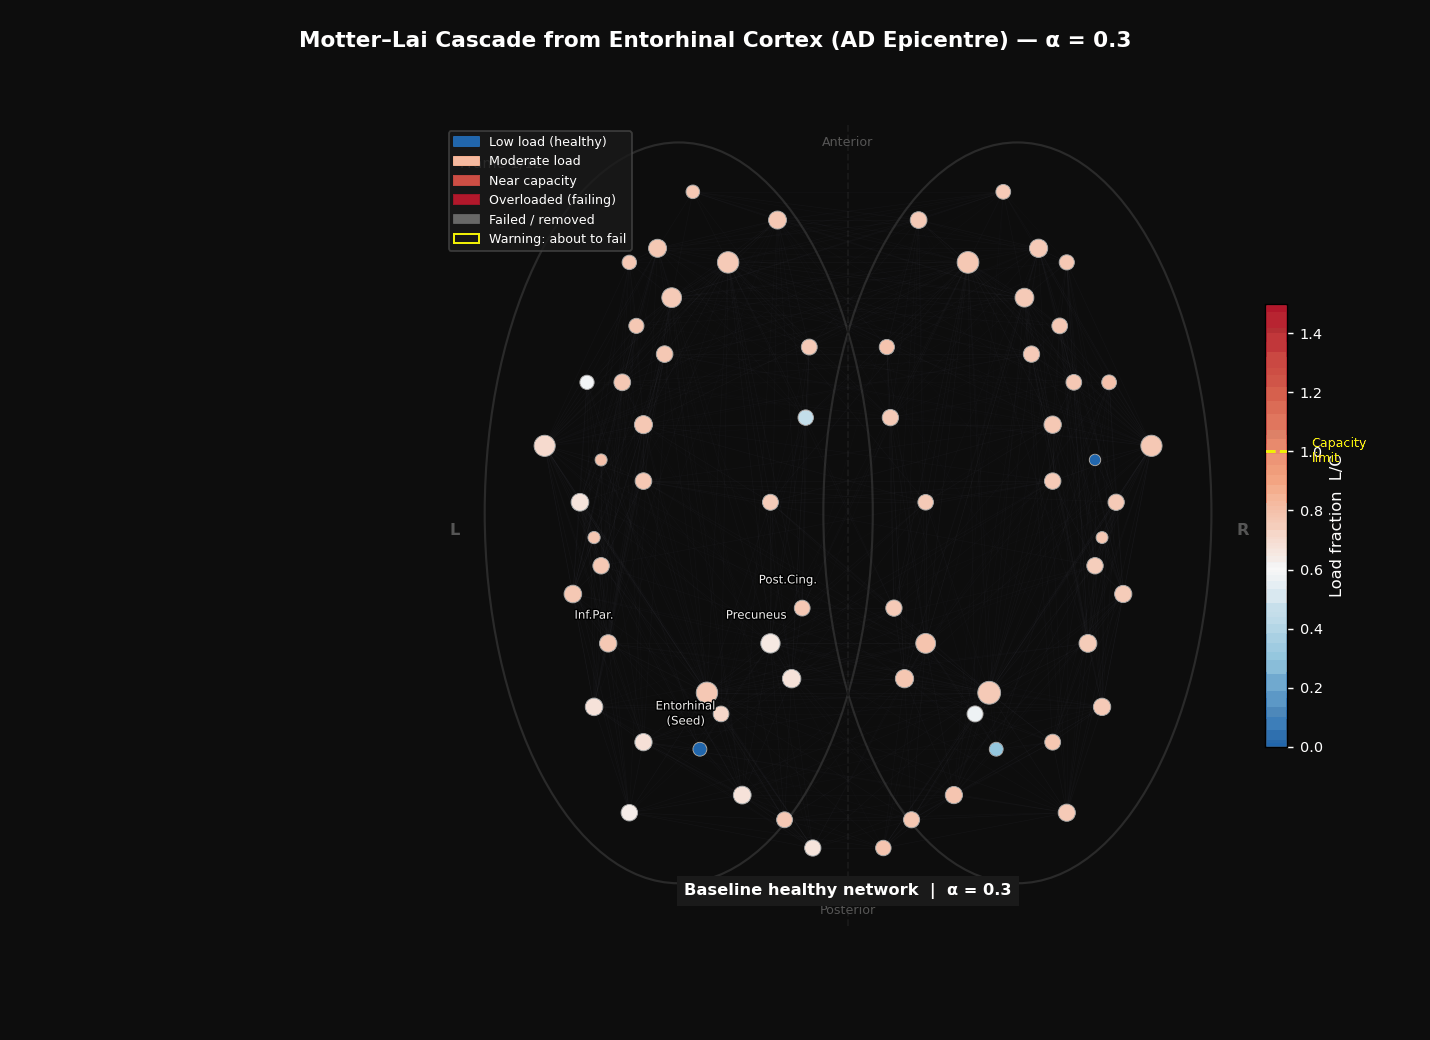

In [9]:
display(Image('ad_motterlai_animation.gif'))

---
## Side-by-Side Static Comparison (Final Frame)

A single static figure showing the final state of both simulations for easy comparison.

In [10]:
fig3, axes3 = plt.subplots(1, 2, figsize=(16, 7))
fig3.patch.set_facecolor('#111111')

titles = ['Biological AD Progression (Braak VI — End-stage)',
          f'Motter–Lai Cascade (α={ALPHA_ANIM}) — Post-cascade Stable State']
cmaps  = [TAU_CMAP, ML_CMAP]
vmaxs  = [1.0, 1.5]
clabels= ['Tau Burden (0=healthy, 1=fully affected)',
          'Load fraction L/C (>1 = overloaded → removed)']

for ax_idx, ax3 in enumerate(axes3):
    ax3.set_facecolor('#111111')
    ax3.set_xlim(-1.15, 1.15)
    ax3.set_ylim(-1.12, 1.15)
    ax3.set_aspect('equal')
    ax3.axis('off')
    ax3.set_title(titles[ax_idx], color='white', fontsize=10, pad=10)

    # Brain outline
    for sign in [-1, 1]:
        e = Ellipse((sign * 0.48, 0.05), width=1.10, height=2.10,
                    linewidth=1.2, edgecolor='#333333', facecolor='none', zorder=1)
        ax3.add_patch(e)
    ax3.axvline(0, color='#222222', lw=1.0, ls='--', zorder=1)

    # Edges
    for (i, j) in EDGES:
        xi, yi = pos[i]; xj, yj = pos[j]
        alp = edge_alpha_from_weight(sc_ctx[i, j], W_MAX, 0.03, 0.15)
        ax3.plot([xi, xj], [yi, yj], '-', color='#666666', alpha=alp, lw=0.3, zorder=2)

    if ax_idx == 0:
        # Bio final state
        tau_final = np.array([tau_trajectory(braak_stage[i], TOTAL_FRAMES - 1) for i in range(N)])
        sc3 = ax3.scatter(node_x, node_y, s=node_size, c=tau_final,
                          cmap=TAU_CMAP, vmin=0, vmax=1.0,
                          edgecolors='white', linewidths=0.4, zorder=5)
        cb3 = fig3.colorbar(sc3, ax=ax3, fraction=0.025, pad=0.01)
        cb3.set_label(clabels[0], color='white', fontsize=8)
        plt.setp(cb3.ax.yaxis.get_ticklabels(), color='white', fontsize=7)
        cb3.ax.yaxis.set_tick_params(color='white')

        # Annotate Braak stages
        stage_labels_map = {1: 'I-II', 2: 'III-IV', 3: 'V-VI'}
        stage_cols_map   = {1: '#fd8d3c', 2: '#d73027', 3: '#67000d'}
        for st_val, st_lab in stage_labels_map.items():
            st_nodes = [i for i in range(N) if braak_stage[i] == st_val]
            if st_nodes:
                cx = np.mean([node_x[i] for i in st_nodes])
                cy = np.mean([node_y[i] for i in st_nodes])
                ax3.text(cx, cy, f'Braak {st_lab}', fontsize=7, color='white',
                         ha='center', va='center', fontweight='bold',
                         bbox=dict(facecolor=stage_cols_map[st_val], alpha=0.7, pad=2),
                         zorder=8)
    else:
        # ML final state
        c_final = np.zeros(N)
        final_load = ml_loads[-1] if ml_loads else {}
        sz_final = node_size.copy()
        edge_fin = ['#aaaaaa'] * N
        for i in range(N):
            if i in all_failed:
                c_final[i] = 0.0
                sz_final[i] = node_size[i] * 0.25
                edge_fin[i] = '#333333'
            else:
                c_final[i] = min(1.5, final_load.get(i, 0.0))

        sc3b = ax3.scatter(node_x, node_y, s=sz_final, c=c_final,
                           cmap=ML_CMAP, vmin=0, vmax=1.5,
                           edgecolors=edge_fin, linewidths=0.5, zorder=5)
        # Mark failed with X
        fail_xy = np.array([[pos[i][0], pos[i][1]] for i in all_failed])
        if len(fail_xy):
            ax3.scatter(fail_xy[:,0], fail_xy[:,1], s=node_size.mean() * 0.5,
                        marker='x', color='#ff4444', linewidths=1.5, zorder=8)

        # Mark seed
        ax3.scatter([pos[entorhinal_seed][0]], [pos[entorhinal_seed][1]],
                    s=200, marker='*', color='#ffdd00', zorder=9)
        ax3.text(pos[entorhinal_seed][0], pos[entorhinal_seed][1] + 0.09,
                 'Seed\n(Entorhinal)', color='#ffdd00', fontsize=7, ha='center',
                 path_effects=[pe.withStroke(linewidth=1.5, foreground='black')], zorder=10)

        cb3b = fig3.colorbar(sc3b, ax=ax3, fraction=0.025, pad=0.01)
        cb3b.set_label(clabels[1], color='white', fontsize=8)
        plt.setp(cb3b.ax.yaxis.get_ticklabels(), color='white', fontsize=7)
        cb3b.ax.yaxis.set_tick_params(color='white')
        cb3b.ax.axhline(1.0, color='yellow', lw=1.2, ls='--')

        surviving = N - len(all_failed)
        ax3.text(0, -1.05, f'{surviving}/{N} regions survive ({surviving/N*100:.0f}%)',
                 ha='center', va='top', color='#aaffaa', fontsize=9, fontweight='bold')

plt.suptitle('Final State Comparison — AD Biology (left) vs Motter–Lai Cascade (right)',
             color='white', fontsize=12, fontweight='bold', y=1.00)
plt.tight_layout()
plt.savefig('ad_final_comparison.png', dpi=150, bbox_inches='tight',
            facecolor='#111111')
plt.show()
print('Saved: ad_final_comparison.png')

Saved: ad_final_comparison.png


/tmp/ipykernel_132541/1910782030.py:100: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


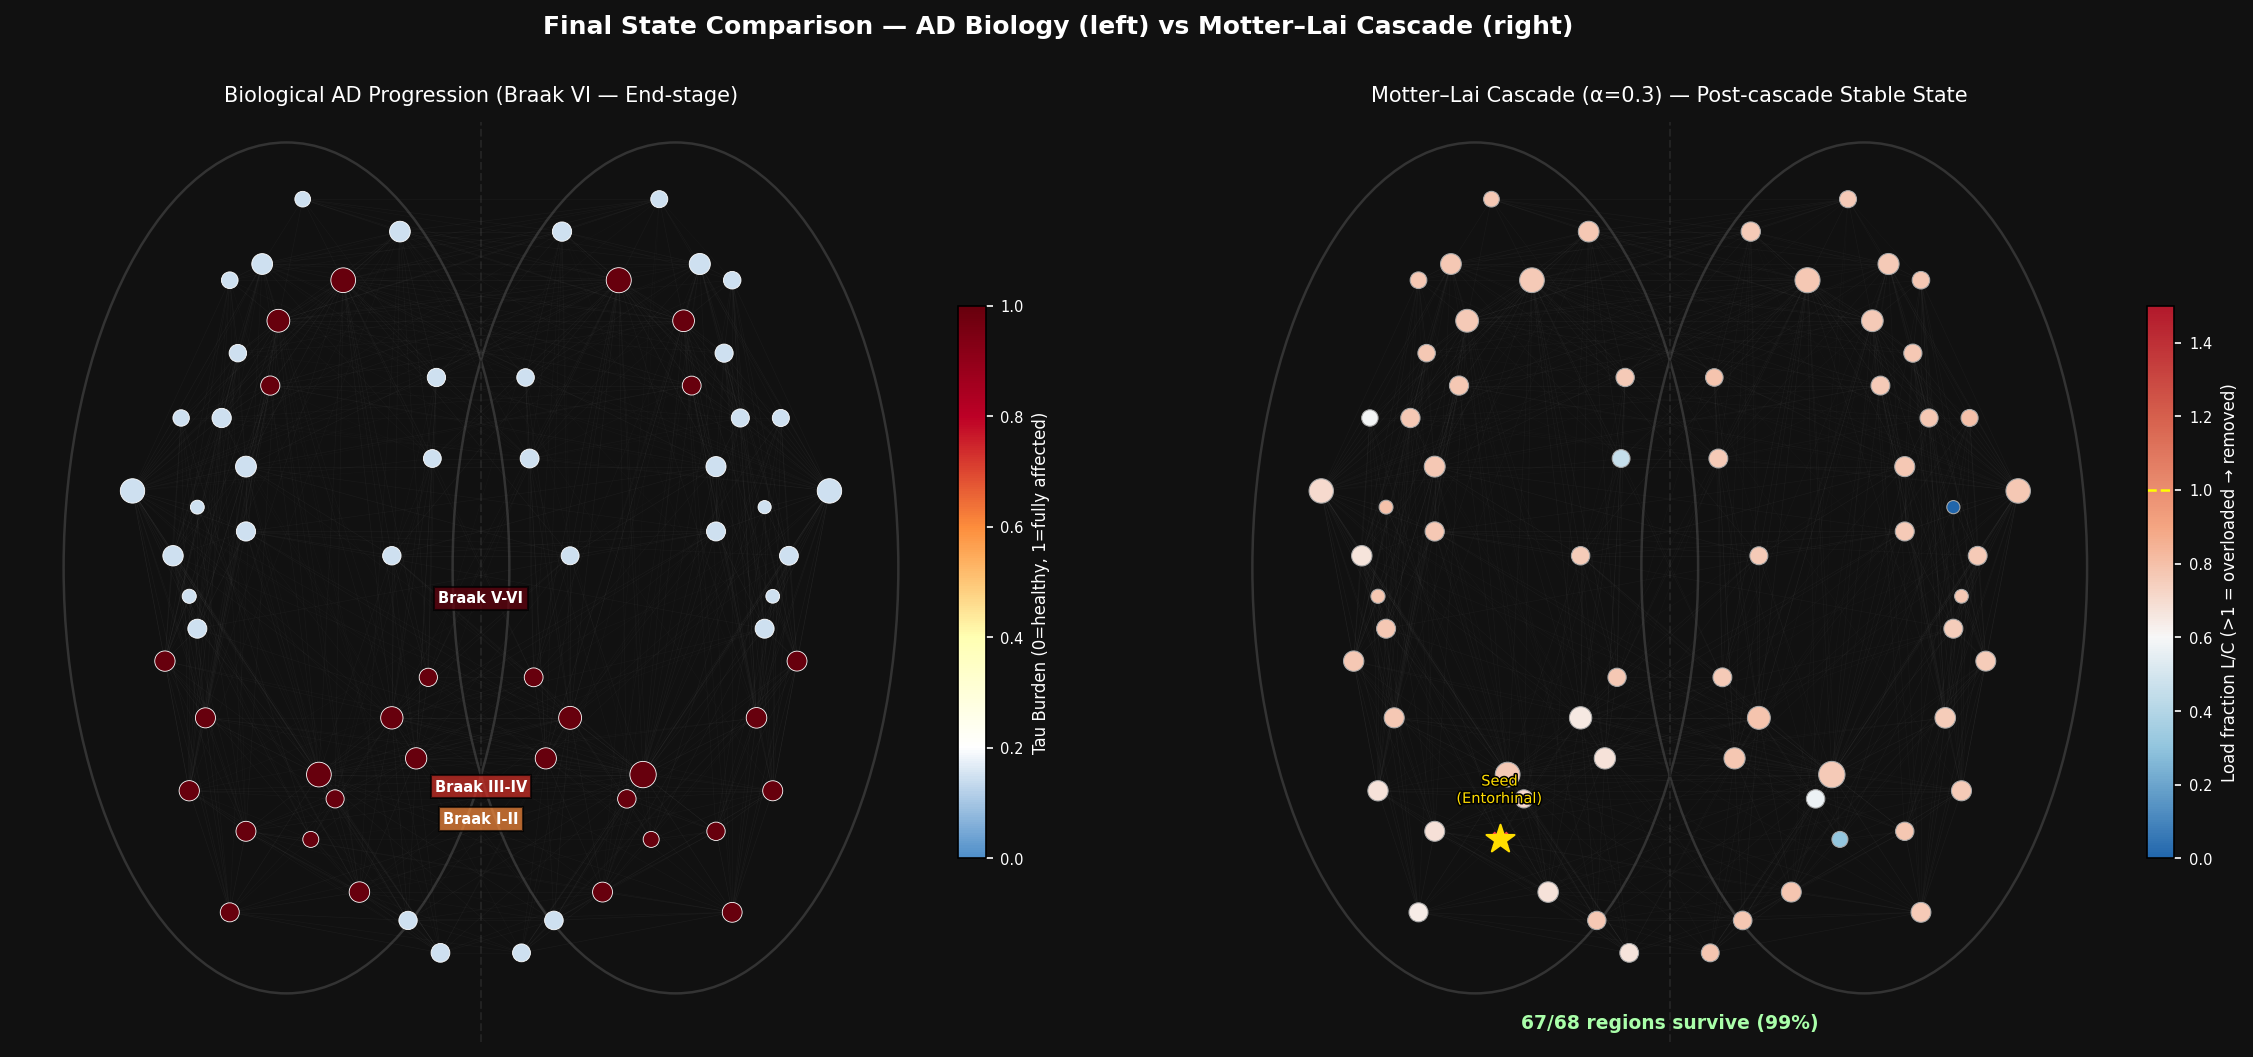

In [11]:
display(Image('ad_final_comparison.png'))